Initial exploratory data analysis to get sense of the data

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.feature_selection import mutual_info_classif as mic
from sklearn.model_selection import train_test_split, cross_val_score

# classifier so lets try logistic regression as simplest, then decision tree, random forest, XGBoost, and a neural network (for later)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore

In [3]:
# loading the data
df = pd.read_csv('data/Credit_Risk_Benchmark_Dataset.csv')

# can see that the dataset is clean with no null values. All containing floats/integers
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16714 entries, 0 to 16713
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rev_util     16714 non-null  float64
 1   age          16714 non-null  float64
 2   late_30_59   16714 non-null  float64
 3   debt_ratio   16714 non-null  float64
 4   monthly_inc  16714 non-null  float64
 5   open_credit  16714 non-null  float64
 6   late_90      16714 non-null  float64
 7   real_estate  16714 non-null  float64
 8   late_60_89   16714 non-null  float64
 9   dependents   16714 non-null  float64
 10  dlq_2yrs     16714 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.4 MB


In [ ]:
df.describe().T

# can see that debt ratio contains very large value, suggesting an oulier
#TODO: think carefully about how to treat the outlier (and loss that want to use? here probably
# not a mistake?  - 
# although perhaps loss fixed at cross entropy for classification and gini impurity anyway?)


# can also see that debt ratio has some insane high values - what is the income for those really large debt ratio values?
# from that could get the debt
# same for revolving utilisation - these values seem pretty insane

,count,mean,std,min,25%,50%,75%,max
rev_util,16714.0,4.799862,204.062345,0.0,0.082397,0.443080,0.926637,22000.0
age,16714.0,48.798672,13.906078,21.0,38.000000,48.000000,58.000000,101.0
late_30_59,16714.0,1.110267,7.172890,0.0,0.000000,0.000000,1.000000,98.0
debt_ratio,16714.0,30.980298,719.694859,0.0,0.155971,0.322299,0.533426,61106.5
monthly_inc,16714.0,6118.120258,5931.841779,0.0,3128.500000,5000.000000,7573.000000,250000.0
open_credit,16714.0,8.503709,5.370965,0.0,5.000000,8.000000,11.000000,57.0
late_90,16714.0,0.863827,7.167576,0.0,0.000000,0.000000,0.000000,98.0
real_estate,16714.0,1.047445,1.272565,0.0,0.000000,1.000000,2.000000,29.0
late_60_89,16714.0,0.734354,7.138737,0.0,0.000000,0.000000,0.000000,98.0
dependents,16714.0,0.944358,1.198791,0.0,0.000000,0.000000,2.000000,8.0


In [ ]:

# when plotting revolving utilisation, can see that vast majoruty over 1 are only slightly (e.g., betwen 1 and 2 times)
# extra 40 samples are below 10 times. extra 4 below 20 times. extra 2 below 100 times etc.

# So cutoff of 10 seems reasonable for revolving utilisation
# majority 2 and 3 times over the limit so cutoff of 5 only results in loss of four more data points - not a big deal - 
# 
# in future, could impute values for utilisation given income and debt.
# BUT because losing so few samples, unlikely going to contirbute to model performance


df[(df['rev_util'] > 5) & (df['rev_util'] < 10)].head(50)
# df[(df['rev_util']  2)].head(50)

,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
3362,8.851852,34.0,0.0,0.168538,12916.0,7.0,0.0,1.0,0.0,0.0,0
9573,5.214381,26.0,0.0,0.704074,1300.0,7.0,0.0,0.0,0.0,0.0,1
9950,8.599600,26.0,2.0,0.418905,1935.0,2.0,0.0,0.0,0.0,2.0,1
16045,7.308970,54.0,2.0,0.152493,3750.0,4.0,2.0,0.0,1.0,1.0,1


<small>
Feature descriptions:

Rev util - revolving utilisation, meaning the percentage (or here proportion) of someones revolving credit that they are currently using.   Revolving credit is credit that someone can borrow, pay back, then use again, e.g., like a credit card. Higher proportion generally more risky. Greater than 100% (or 1 if proportion) means that someone is is using more than their allowance

Late_30_59, late_60_89, late_90 - Delinquency (failure to pay by the due date) variables - Gives counts for number of times someone has been 30-59, 60-89 or 90+ days late for paying back credit, within a given period (need to check period here). more times = worse

Real_estate - number of real estate loans or credit lines

Debt_ratio - Debt to income ratio
<small>

In [36]:
# check for missing data etc
# can see that the data we have been given conveniently contains equal amounts of either class
df['dlq_2yrs'].value_counts()

dlq_2yrs
0    8357
1    8357
Name: count, dtype: int64

In [291]:
# some points have high number of open credit

# df[(df['open_credit'] > 5)].head(50)
df[(df['real_estate'] > 10)].head(50)

,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
8481,0.451376,48.0,0.0,2.511961,12080.0,29.0,0.0,17.0,0.0,2.0,1
8601,0.963012,39.0,2.0,3.173399,5916.0,19.0,0.0,12.0,0.0,2.0,1
9358,0.239849,41.0,1.0,0.860609,15000.0,23.0,0.0,12.0,0.0,3.0,1
9533,0.116671,59.0,0.0,0.522241,13600.0,20.0,0.0,12.0,0.0,0.0,1
10721,0.786698,33.0,0.0,2.355149,4048.0,15.0,0.0,13.0,0.0,0.0,1
12008,0.036942,43.0,0.0,0.719174,55966.0,41.0,0.0,29.0,0.0,0.0,1
12326,0.626482,46.0,0.0,0.738863,13333.0,21.0,0.0,11.0,0.0,0.0,1
12430,0.158597,33.0,0.0,0.702016,18500.0,36.0,0.0,13.0,0.0,0.0,1
12573,0.622960,46.0,4.0,0.704228,10666.0,18.0,0.0,13.0,0.0,1.0,1
12622,0.152837,36.0,1.0,2.516039,12500.0,28.0,0.0,15.0,0.0,0.0,1


shape before: 
 (4, 3)
shape after: 
 (12,)



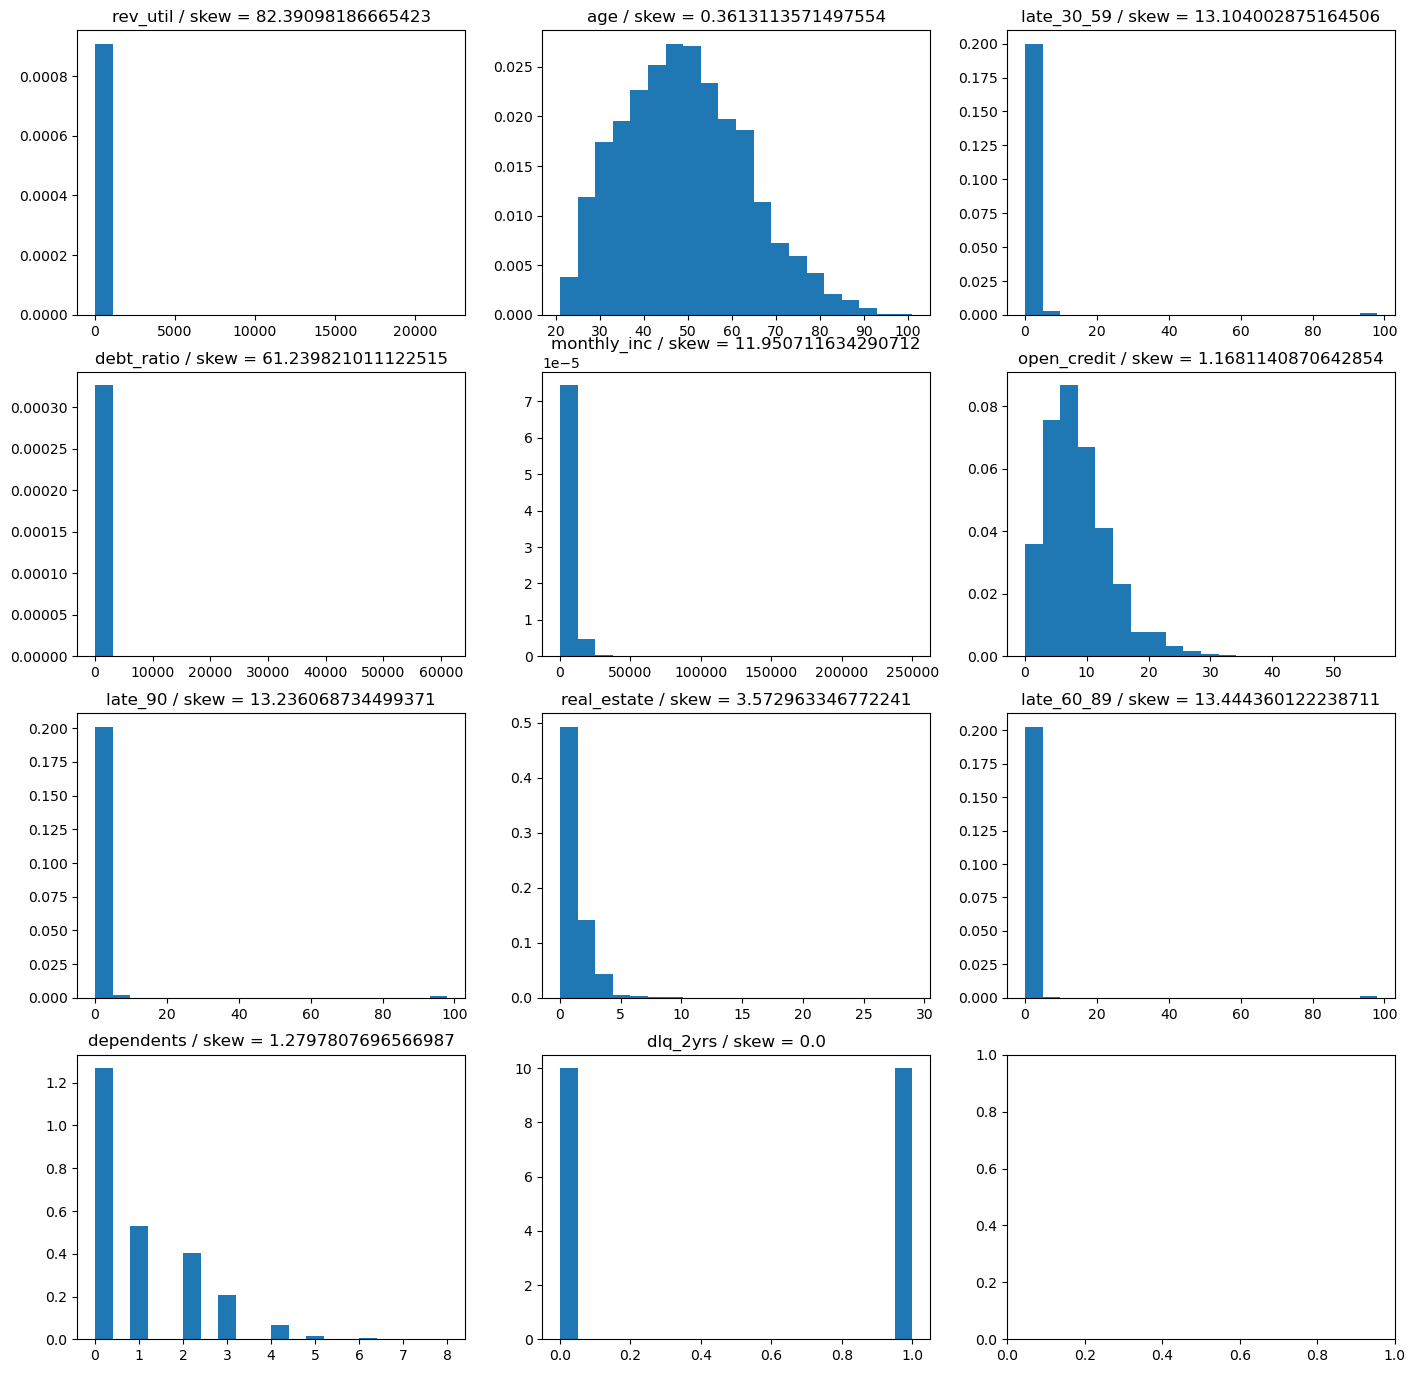

In [15]:
# only 11 features, so lets try and plot the distributions of each variable to understand them

#TODO: check for values at differing percentiles - if 0th and 25th percentile differ significantly, 
# then probably have outliers

# making figure size bigger gives more space for subplots so no overlap
fig, axs = plt.subplots(4, 3, figsize=(17, 17))

print('shape before: \n', axs.shape)
print('shape after: \n', axs.flatten().shape)
print()
for i, ax in enumerate(axs.flatten()[:-1]):
    # print(i)
    ax.hist(df.iloc[:, i], bins=20, density=True)

    # put skew of data into histogram
    ax.set_title(str(df.columns[i] + ' ' + f'/ skew = {df.iloc[:, i].skew()}'))



plt.show()

In [ ]:
# from the above, can see that some columns look to give binary values, given that majoruty values are one or zero.
# however, there are some bars further along in plot, suggesting that something fishy going on

# seems that late_60_89 and late_90+ have weird number of instances for 98 and 96 times delayed.
# before that, people usually no more than 13 times late for payment - this must be a bug of sorts
print(df['debt_ratio'].value_counts())

# for example, rev util

debt_ratio
0.000000      405
1.000000        5
0.007664        3
0.216594        3
0.001999        3
             ... 
170.398010      1
0.845887        1
0.176732        1
0.064116        1
0.057235        1
Name: count, Length: 16128, dtype: int64


shape before: 
 (4, 3)
shape after: 
 (12,)



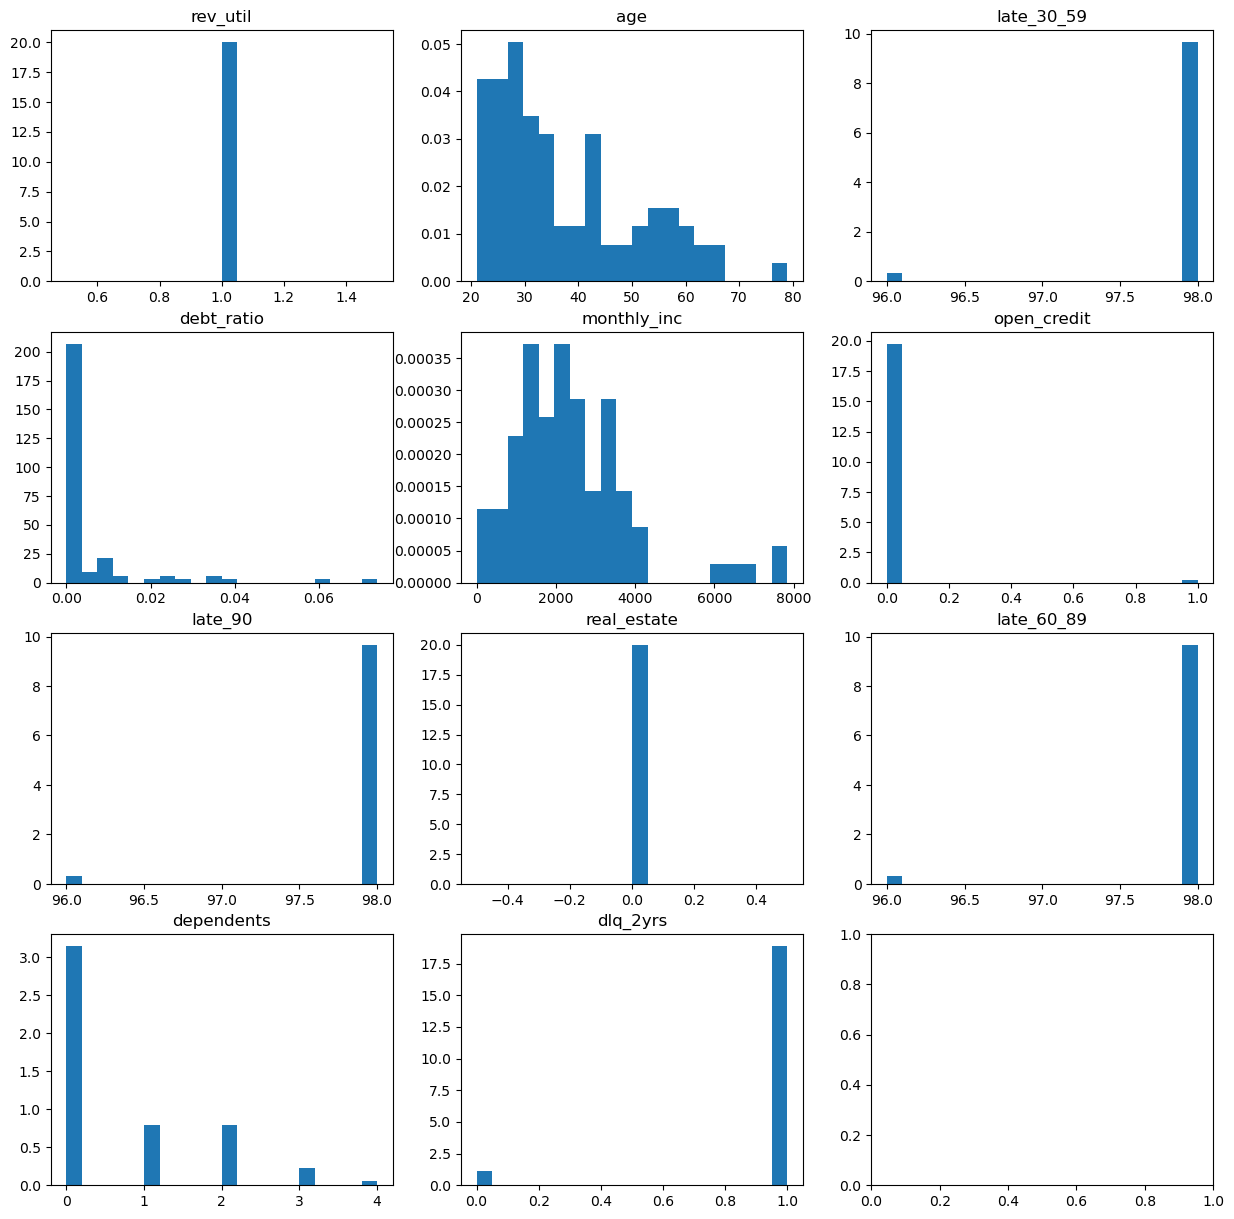

In [38]:
#  so lets try filter for where variable has 98/96 times deinquency to see what characteristics of data are in this case

df_delinquency = df[(df['late_90'] == 98) | (df['late_90'] == 96) | (df['late_60_89'] == 96) |(df['late_60_89'] == 98) ]

# making figure size bigger gives more space for subplots so no overlap
fig, axs = plt.subplots(4, 3, figsize=(15, 15))

print('shape before: \n', axs.shape)
print('shape after: \n', axs.flatten().shape)
print()
for i, ax in enumerate(axs.flatten()[:-1]):
    # print(i)
    ax.hist(df_delinquency.iloc[:, i], bins=20, density=True)
    ax.set_title(str(df.columns[i]))

plt.show()

In [39]:
# all these people are using exactly all of their current credit allowance
# they are aways equally late to paying, like they have gamed the system?
# all bar 5 have defaulted.
# aside from this doesn;t seem to be anything special about these people (maybe they just took out loans and went AWOL)
# for now just remove because don't look like they would add any new information to the data anyway?
# TODO: come up with hypothesis for what happening and could try imputing/other things to correct if wrong in some way

print(df_delinquency['rev_util'].value_counts())
print(df_delinquency['dlq_2yrs'].value_counts())

rev_util
1.0    89
Name: count, dtype: int64
dlq_2yrs
1    84
0     5
Name: count, dtype: int64


In [132]:
# filter the dataframe
df_filtered = df[(df['late_90'] != 98) & (df['late_90'] != 96)]

# check valuecounts
print(df_filtered['late_90'].value_counts())
# print(df['late_60_89'].value_counts())
# print(df['late_30_59'].value_counts())
print(df_filtered['dlq_2yrs'].value_counts())


late_90
0.0     13626
1.0      1667
2.0       675
3.0       327
4.0       169
5.0        67
6.0        38
7.0        22
9.0        11
8.0        10
10.0        5
11.0        3
13.0        2
17.0        1
14.0        1
12.0        1
Name: count, dtype: int64
dlq_2yrs
0    8352
1    8273
Name: count, dtype: int64


shape before: 
 (4, 3)
shape after: 
 (12,)



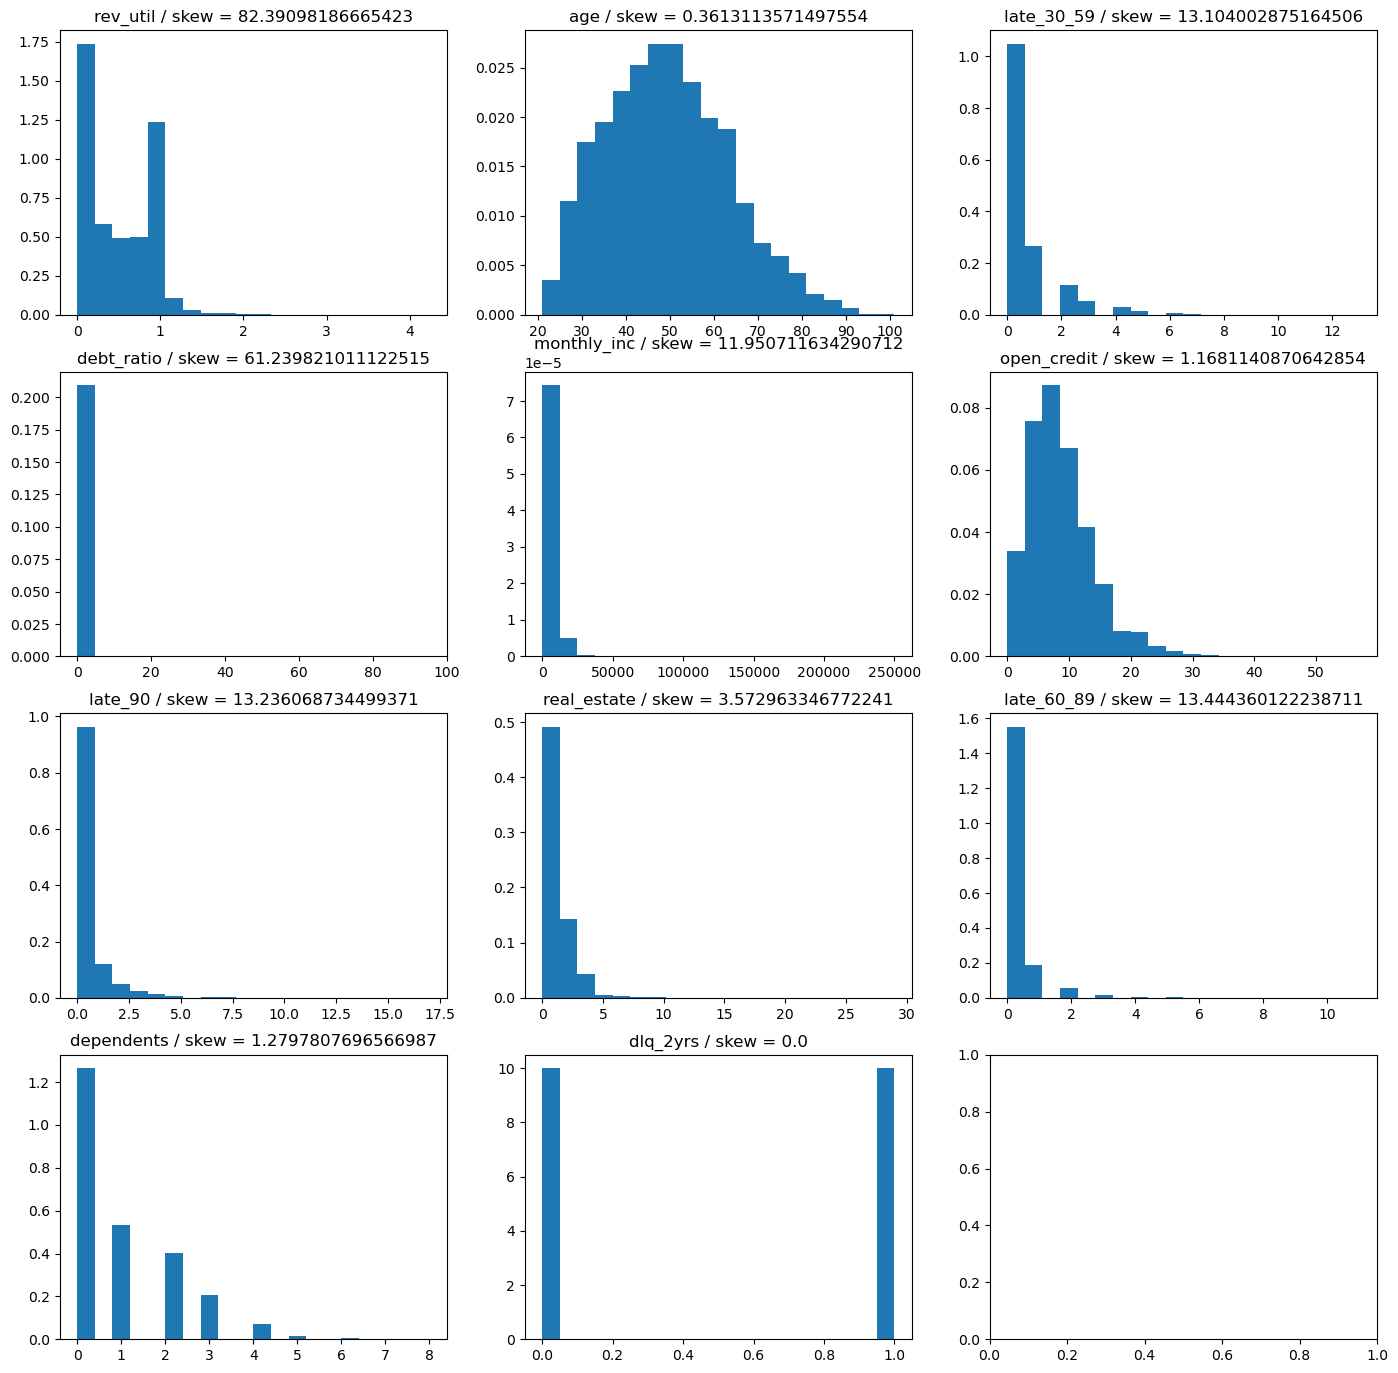

In [279]:
# making figure size bigger gives more space for subplots so no overlap
fig, axs = plt.subplots(4, 3, figsize=(17, 17))

print('shape before: \n', axs.shape)
print('shape after: \n', axs.flatten().shape)
print()
for i, ax in enumerate(axs.flatten()[:-1]):
    # print(i)
    ax.hist(df_filtered.iloc[:, i], bins=20, density=True)

    # put skew of data into histogram
    ax.set_title(str(df_filtered.columns[i] + ' ' + f'/ skew = {df.iloc[:, i].skew()}'))

In [ ]:
# checking the debt ratio values

df_large_debt_ratio = df_filtered[df_filtered['debt_ratio'] > 100]

df_filtered[df['monthly_inc'] == 1].count()


# can see that some people with monthly income of 1 ans some with monthly income of zero
# this causes debt ratio to be very large - worth including in training data?


# df_filtered['monthly_inc'].value_counts()
# can see that alot of these large values have a monthly income of 0 or 1 (so no income or 
# have income of £1). Because of this, debt ratio becomes very large

# plt.hist(df_large_debt_ratio['monthly_inc'], bins=10, density=True)
# plt.show()
# # set up axis before iterating over
# fig, axs = plt.subplots(4, 3, figsize=(17, 17))

# for i, ax in enumerate(axs.flatten()[:-1]):
#     # print(i)
#     ax.hist(df_large_debt_ratio.iloc[:, i], bins=10, density=True)

#     # put skew of data into histogram
#     ax.set_title(str(df_large_debt_ratio.columns[i] + ' ' + f'/ skew = {df.iloc[:, i].skew()}'))

C:\Users\Flynn\AppData\Local\Temp\ipykernel_7708\3225696227.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered[df['monthly_inc'] == 3].count()


rev_util          0
age               0
late_30_59        0
debt_ratio        0
monthly_inc       0
open_credit       0
late_90           0
real_estate       0
late_60_89        0
dependents        0
dlq_2yrs          0
binned_feature    0
dtype: int64

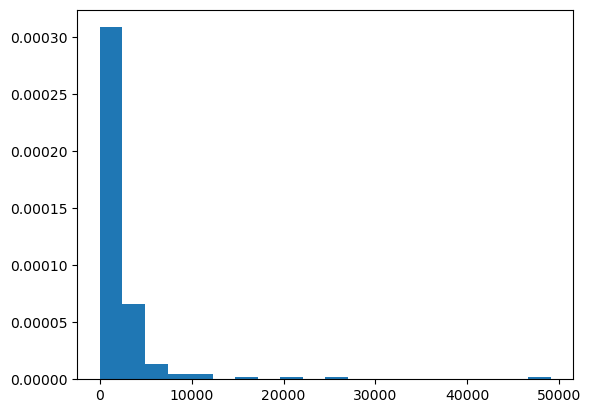

debt_ratio
0.0       10
1.0        3
130.0      2
223.0      2
21.0       2
          ..
1642.0     1
1895.0     1
2150.0     1
977.0      1
2662.0     1
Name: count, Length: 160, dtype: int64


In [ ]:
# get data where monthly income is 1 or zero

df_low_income = df_filtered[df_filtered['monthly_inc'] == 0]

# to see anomalous data, can look to see if debt ratio is defined for these
plt.hist(df_low_income['debt_ratio'], bins=20, density=True)
plt.show()

print(df_low_income['debt_ratio'].value_counts())
# can see that many of these points have debt ratio that is not zero. Very suspicous. 
# suggests that those data points are probably incorrect

# monthlyl income of 1 is also very unusual. Very unlikely that this is correct either,
# so probably want to filter for these data points


Do all filtering in one place

In [4]:
# mask out data for revolving utilisation greater than 5

print('initial shape: \n', df.shape)
df_filtered = df[df['rev_util'] < 5]

print(df_filtered.shape)

df_high_rev = df[df['rev_util'] > 5]

# filter out bad values for late 90 etc.
df_filtered = df_filtered[(df['late_90'] != 98) & (df['late_90'] != 96)]

print(df_filtered.shape)
# filter out bad values for monthly income (where equal to 1 or zero - very likely an error)
mask_inc_bad_data = (df_filtered['monthly_inc'] == 1) | ((df_filtered['monthly_inc'] == 0) & (df_filtered['debt_ratio'] != 0))
df_filtered = df_filtered[~mask_inc_bad_data]

print(df_filtered.shape)

# create mask where extreme debt ratio coincide with extreme monthly income

mask_debt_ratio_bad_data = ((zscore(df_filtered['debt_ratio']) > 5) & (df_filtered['monthly_inc'] < 500))
# given z score choice is arbitrary, check for data that was removed.
df_extremes = df_filtered[mask_debt_ratio_bad_data]
# filter out debt ratio where 5 standard deviations away from the mean
df_filtered = df_filtered[~mask_debt_ratio_bad_data]

print(df_filtered.shape)
# this removes 9 samples, so unlikely to have large effect upon data

#loss of about 400 out of 16000 data points - ~2.5%


initial shape: 
 (16714, 11)
(16686, 11)
(16597, 11)
(16362, 11)
(16353, 11)


C:\Users\Flynn\AppData\Local\Temp\ipykernel_17336\1035620887.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df_filtered[(df['late_90'] != 98) & (df['late_90'] != 96)]


shape before: 
 (4, 3)
shape after: 
 (12,)



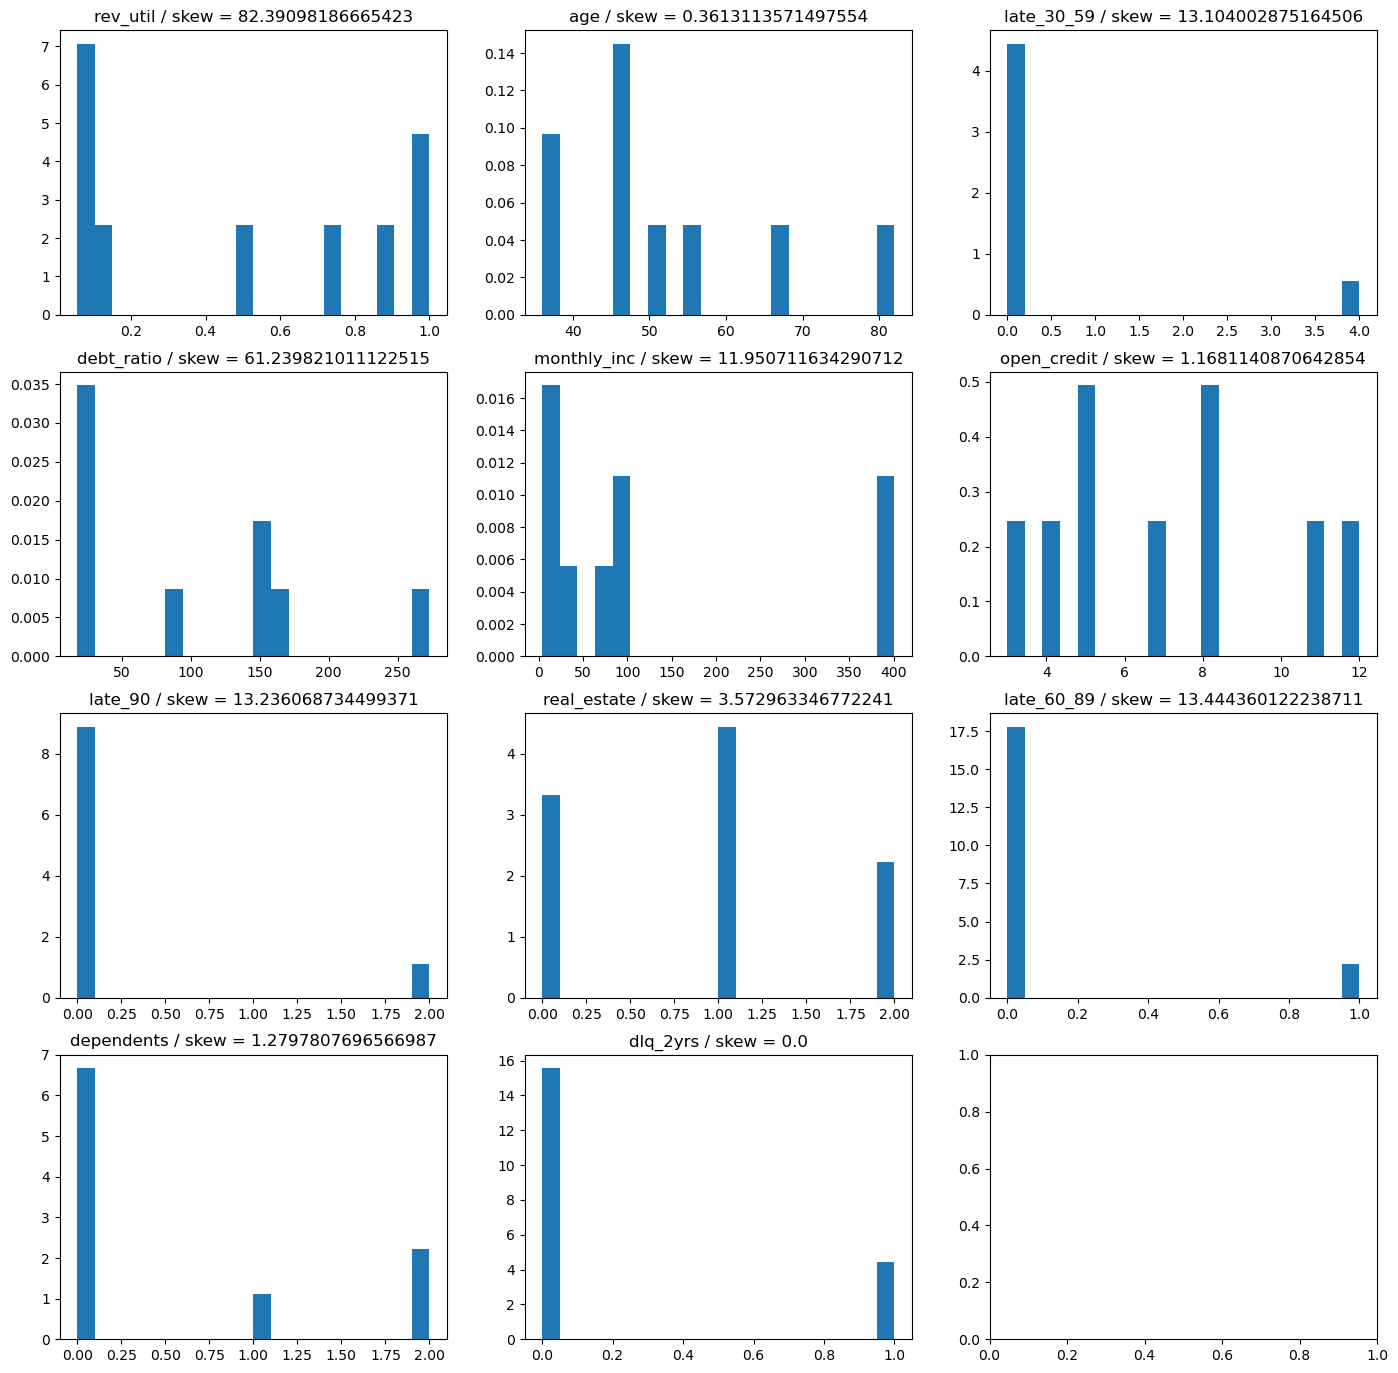

In [215]:
df_extremes.head(50)

fig, axs = plt.subplots(4, 3, figsize=(17, 17))

print('shape before: \n', axs.shape)
print('shape after: \n', axs.flatten().shape)
print()
for i, ax in enumerate(axs.flatten()[:-1]):
    # print(i)
    ax.hist(df_extremes.iloc[:, i], bins=20, density=True)

    # put skew of data into histogram
    ax.set_title(str(df_extremes.columns[i] + ' ' + f'/ skew = {df.iloc[:, i].skew()}'))


shape before: 
 (4, 3)
shape after: 
 (12,)



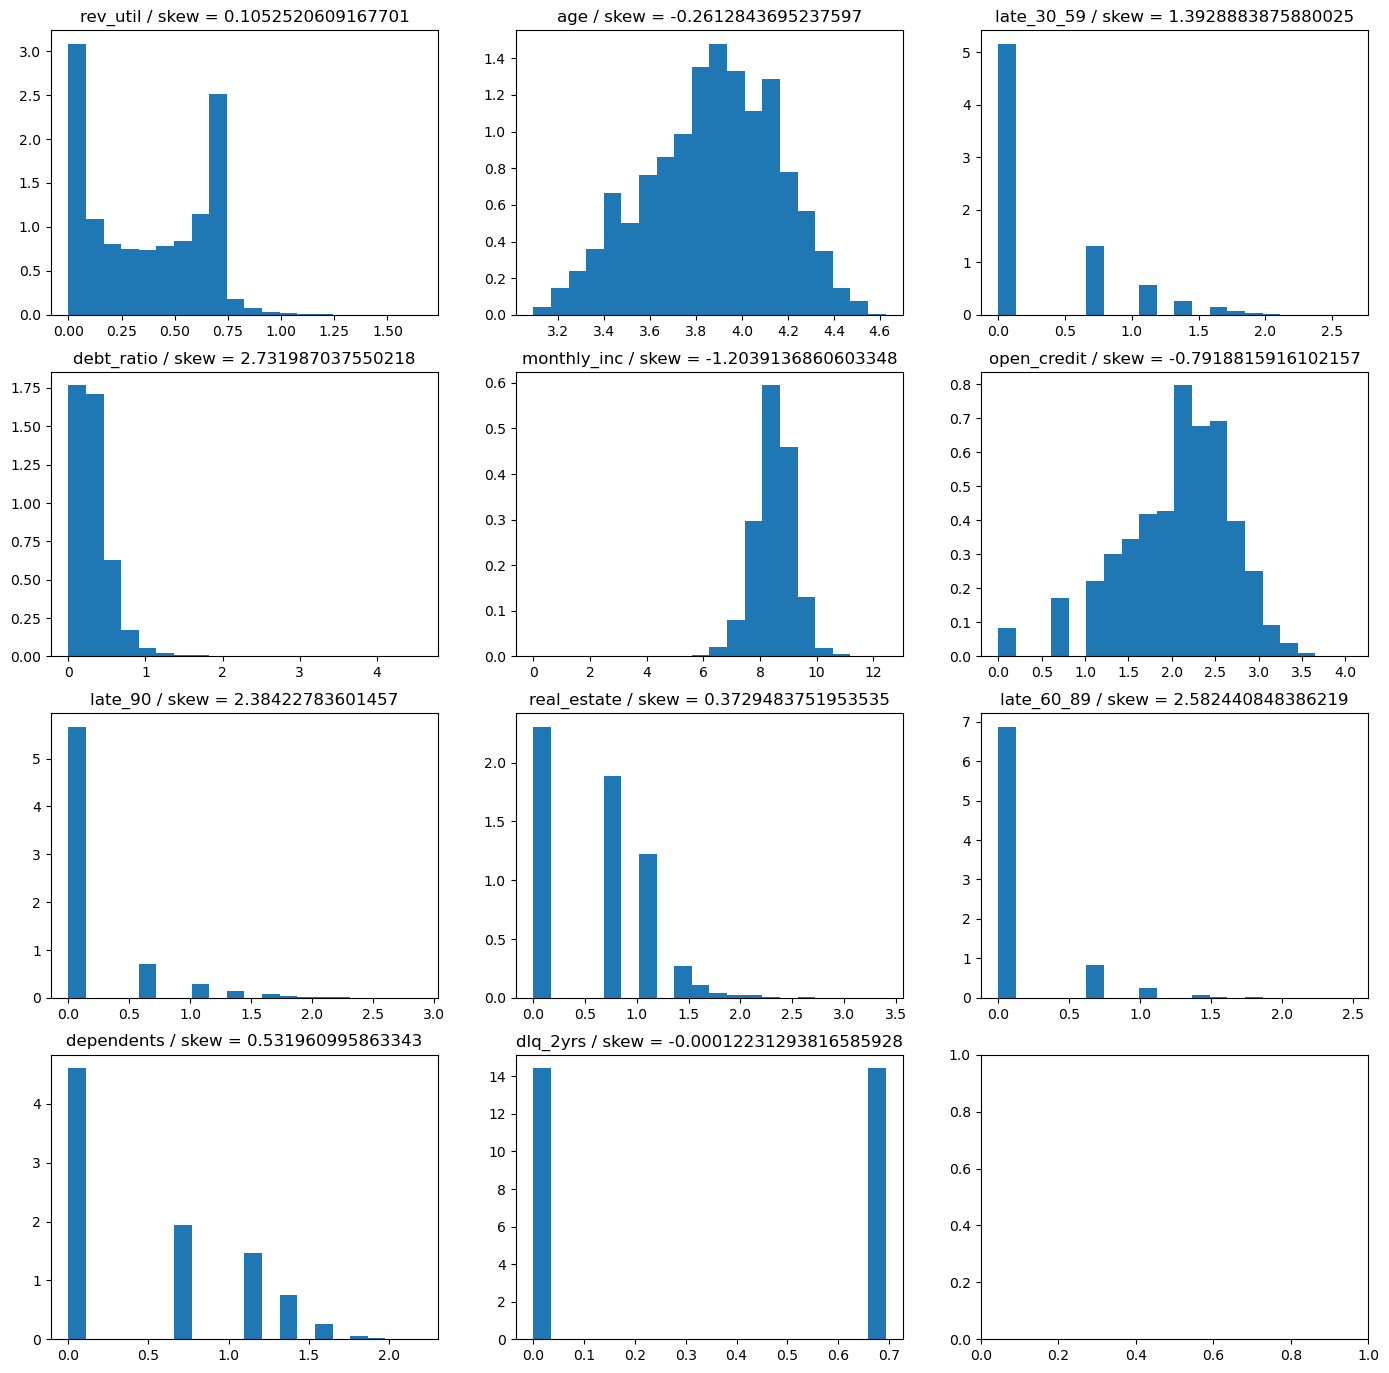

In [6]:
# do same as above plot but instead plot the log1p of each variable
# making figure size bigger gives more space for subplots so no overlap
fig, axs = plt.subplots(4, 3, figsize=(17, 17))

print('shape before: \n', axs.shape)
print('shape after: \n', axs.flatten().shape)
print()
for i, ax in enumerate(axs.flatten()[:-1]):
    # print(i)
    ax.hist(np.log1p(df_filtered.iloc[:, i]), bins=20, density=True)

    # put skew of data into histogram
    ax.set_title(str(df_filtered.columns[i] + ' ' + f'/ skew = {np.log1p(df_filtered.iloc[:, i]).skew()}'))

plt.show()

In [ ]:
# plotting scatter plot of skewed distr

In [237]:
# fig, axs = plt.subplots(4, 3, figsize=(17, 17))

# print('shape before: \n', axs.shape)
# print('shape after: \n', axs.flatten().shape)
# print()
# for i, ax in enumerate(axs.flatten()[:-1]):
#     # print(i)
#     ax.hist(df_high_rev.iloc[:, i], bins=20, density=True)

#     # put skew of data into histogram
#     ax.set_title(str(df_high_rev.columns[i] + ' ' + f'/ skew = {df.iloc[:, i].skew()}'))

df_high_rev.describe().T
df_high_rev.head(50)
# can see that large revolving credit often have a very small debt ratio

,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
2297,22000.0,38.0,0.0,1.080020,3973.0,7.0,0.0,2.0,0.0,3.0,0
3202,6726.0,43.0,0.0,2.823035,1666.0,6.0,0.0,2.0,0.0,3.0,0
3321,3677.0,43.0,0.0,0.208722,20500.0,2.0,0.0,1.0,0.0,3.0,0
4886,5423.0,44.0,1.0,0.226619,18550.0,9.0,0.0,3.0,0.0,0.0,0
6635,2120.0,56.0,2.0,0.723538,3334.0,3.0,0.0,1.0,0.0,1.0,0
6997,1563.0,67.0,0.0,0.270838,4570.0,8.0,0.0,0.0,0.0,0.0,0
7149,5015.0,31.0,0.0,0.406842,6225.0,8.0,0.0,1.0,0.0,0.0,0
8394,2066.0,58.0,0.0,0.271121,6000.0,8.0,1.0,1.0,0.0,1.0,1
8452,1143.0,44.0,2.0,0.547762,6500.0,13.0,0.0,4.0,0.0,2.0,1
8753,1577.0,37.0,0.0,0.479826,5526.0,11.0,0.0,2.0,0.0,2.0,1


In [270]:
# can see that remaining people with no monthly income have no debt ratio
df_filtered.describe().T
# but stil have some people with very low income (<100)
# who also represent people with highest income to debt ratio.

# also people with revolving utilisation larger than 1 - this is clearly incorrect

# df_filtered[df_filtered['monthly_inc'] < 1000].head(50)

,count,mean,std,min,25%,50%,75%,max
rev_util,16353.0,0.499772,0.418500,0.0,0.081986,0.439667,0.920114,4.237015
age,16353.0,48.902709,13.859395,21.0,39.000000,48.000000,58.000000,101.000000
late_30_59,16353.0,0.594570,1.129137,0.0,0.000000,0.000000,1.000000,13.000000
debt_ratio,16353.0,0.432455,1.076594,0.0,0.156369,0.319387,0.522944,95.300922
monthly_inc,16353.0,6229.779490,5938.943988,0.0,3238.000000,5000.000000,7650.000000,250000.000000
open_credit,16353.0,8.564789,5.354402,0.0,5.000000,8.000000,11.000000,57.000000
late_90,16353.0,0.345319,0.965177,0.0,0.000000,0.000000,0.000000,17.000000
real_estate,16353.0,1.055586,1.275102,0.0,0.000000,1.000000,2.000000,29.000000
late_60_89,16353.0,0.214395,0.617560,0.0,0.000000,0.000000,0.000000,11.000000
dependents,16353.0,0.945392,1.198709,0.0,0.000000,0.000000,2.000000,8.000000


Rather than using an ML algorithm to define data points to remove (and thus make more assumptions), better to use domain knowledge and a more transparent approach. 
Can see that larger debt ratios can occur where income is low. So could use Z score in combination with threshold for income, to remove erroneous data points

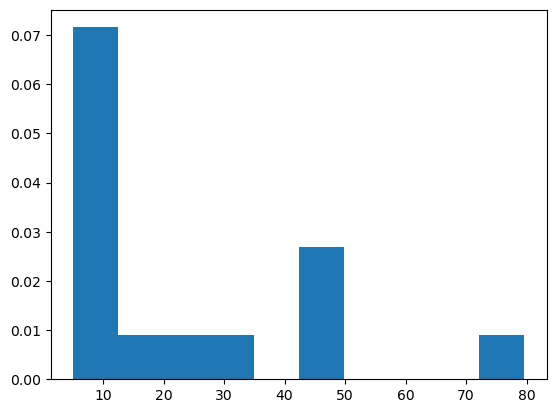

In [ ]:
# get Z score for debt ratio

from scipy.stats import zscore

# compute z scores
debt_ratio_z = zscore(df_filtered['debt_ratio'])

# z score greater than 5 standard deviations from mean very likely erroneous so remove this



plt.hist(debt_ratio_z[debt_ratio_z > 5], density=True)
plt.show()

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import FunctionTransformer


# custom transformer
log_scaler = FunctionTransformer(func=np.log1p)

# get features
X = df_filtered.drop(columns='dlq_2yrs')
y = df_filtered['dlq_2yrs']
# initial scaling with log transformer (to compress extreme values)
log_scaler.fit(X)
X_scaled = log_scaler.transform(X)

scaler_stand = StandardScaler()
scaler_stand.fit(X_scaled)
# then standardise features for PCA (to remove mean)
X_scaled2 = scaler_stand.transform(X_scaled)

# then initialise PCA transformer. for now, keep all components
pca = PCA()

# then fit transformer to features (fit_transform fits and transforms in one go)
X_pca = pca.fit_transform(X_scaled2)

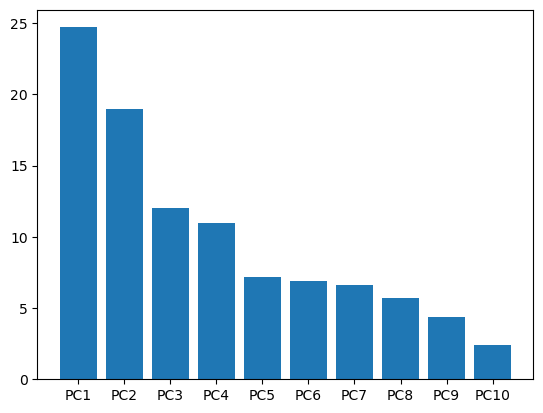

In [18]:
# compute percentage variation each principal component accounts for
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)

# create labels for PCA components
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

# and plot the scree plot
plt.bar(range(1, len(per_var)+1), per_var, tick_label=labels)
plt.show()

# can see that when doing the PCA, there is not a clear distinction between the 1st, 
# second and so on components.

# so data is high dimensional in a meaningul way (i.e., dimensions contribute to the target)

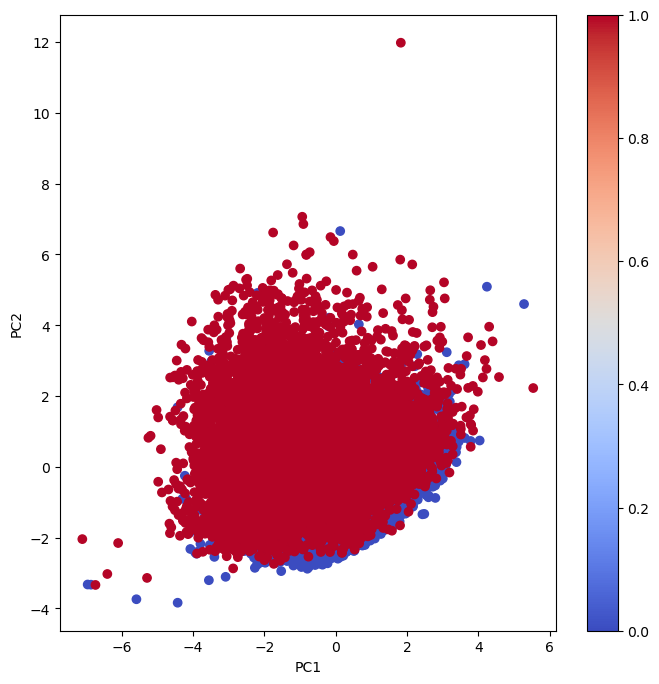

In [282]:
# try plotting the PCA (although note that don't do very good job of seperating the data)
plt.figure(figsize=(8, 8))

# PCA has two dimenions, column is the principal component, its value given for each row in the dataset
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()
plt.show()


# print(X_pca.shape)

# can see that principal components don't seem to seperate out into any clusters, but there are outliers


<Axes: >

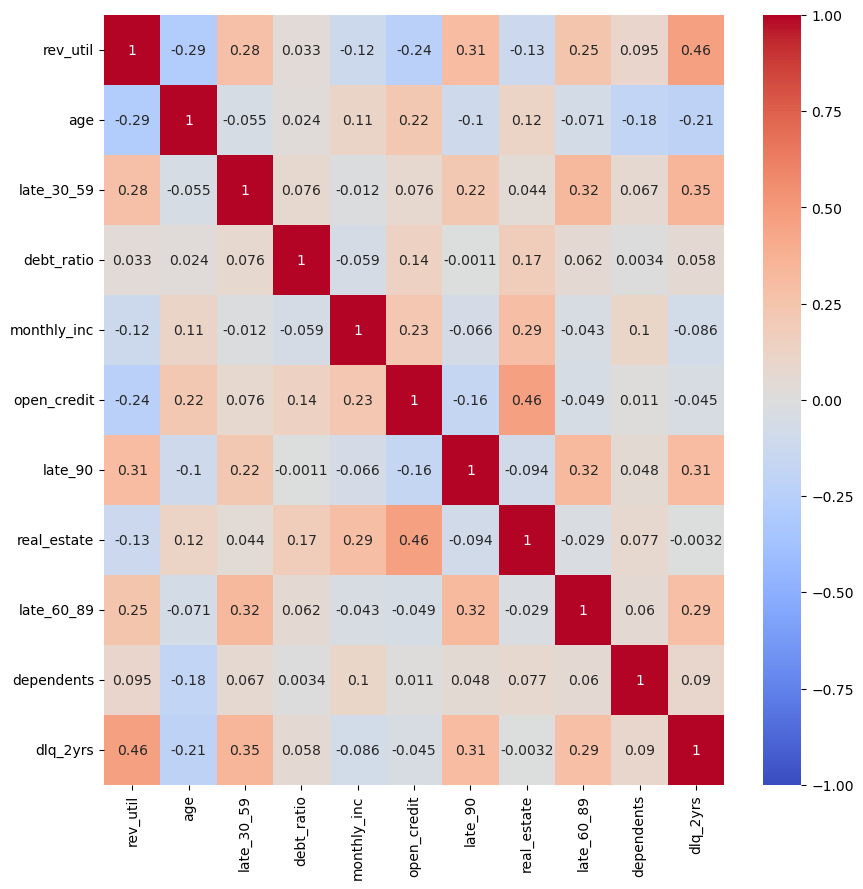

In [19]:
# now values look legitimate, start checking features/feature engineering

# first just a simple correlation check (given all have 'continous' values in a sense)

correlation_matrix = df_filtered.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, vmax=1, vmin=-1)

# visual but not the most informative. 
# can generally see that dlq unsuprisingly correlated with being late on payment

In [ ]:

#TODO: check multi-colinearity as could influence logistic regression! (should not affect decision tree algorithms)
#TODO: USE pipeline to avoid data leakage!!
#TODO: Can do cross validation using multiple models (with different scaling of input arguments for example
#, or using PCA, using a pipeline)

#TODO: try PCA or reducing dimensionality of the data
#TODO: look up sklearn pipeline and what that means and whether could use
#TODO: figure out means to create synthetic data with similarish characterstics to the training data?

#TODO: use a YAML or JSON file for configuration settings

In [20]:
# seperate out features from target
X = df_filtered.drop(columns=['dlq_2yrs'])
y = df_filtered['dlq_2yrs']

In [58]:
# checking for multicolinearity

# # then loop through to get VIF scores for each variable (indicating multicolinearity)
# vif = [variance_inflation_factor(X_values, i) for i in range(X_values.shape[1])]


df_vif_data = pd.DataFrame(data=X.columns)

df_vif_data['vif'] = [variance_inflation_factor(X.values, i) for i in range(X.values.shape[1])]

df_vif_data

# from this, can see that interestingly, age and open credit show highest multi-colinearity 
# - kind of on borderline of 5. prob worthtesting with and without for logistic regression to see if makes difference

,0,vif
0,rev_util,2.477054
1,age,5.031382
2,late_30_59,1.553154
3,debt_ratio,1.230334
4,monthly_inc,2.371547
5,open_credit,4.781840
6,late_90,1.368559
7,real_estate,2.308031
8,late_60_89,1.368421
9,dependents,1.611731


Index(['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc',
       'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents',
       'dlq_2yrs'],
      dtype='str')
[0.12121069 0.02196926 0.08324296 0.01409799 0.00887055 0.00672765
 0.08193568 0.00667282 0.0597427  0.00824748]


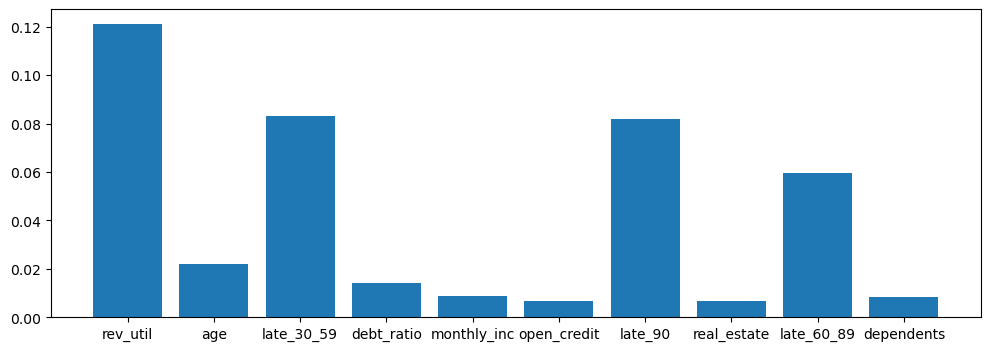

In [21]:
# Use mutual information to identify important features (or features that overlap with one another)
# insert the features and target
print(df_filtered.columns)
mi_score = mic(X, y)

print(mi_score)

plt.figure(figsize=(12, 4))
plt.bar(x=X.columns, height=mi_score)
plt.show()

# from mutual information, can see that amount of credit currently using, and whether they 
# been late paying has strongest influence (interestingly less so for longest)

# age and open credit 

In [22]:
# From above, can for now just remove features where entropy is greater than zero (TODO: would want
# to implement with tolerance)

# NOTE: for now this keep all features but will iterate on this

# get index of MI values that greater than 0.01
mi_score_selected_index = np.nonzero(mi_score)[0] # np.where(mi_score > 0.01)[0]

# #TODO: could just create a feature that gives whether 30+ days late on payment at all (check co-linearity of these)

# # use mi score index to index into features, to remove those below the mi threshold
# X_filtered = X.iloc[:, mi_score_selected_index]

# # print to check
# X_filtered.columns

In [ ]:


#TODO: need to look up what 'sparseness' in data/sparse matrices mean! as well as kernel matrix

#TODO: use train test split to create a final hold out test dataset that has been untouched during production
# (not touched during production)

#TODO: at some point, could plot learning curve to show extent to which model performance on test
# data improves with more data

#TODO: remove features after train initial model, to see if performance degrades after doing so. If little 
# degradation, then keep the feature out

#TODO: will probably try removing features later to see if that process speeds up inference by much without 
# loss in performance, otherwise could keep features

#TODO make sure that log down bugs in places whenever I fix them

#TODO come back later for testing neural network after having created classical version first

Test feature engineering to get a log of odds of a transformed feature that is a straight line.#

Prefer this to splines for now just because there is clear cubic relationship in the graph.
Income and open credit show more of a right skewed relationship in the log of odds space.
Although when logging, can see that not exactly linear, so can try and include squared and cubed terms for these as well

while this may introduce colinearity, can use regularisation to deal with this instead

In [ ]:
#TODO: check out polynomial and spline transformers for feature engineering

df_filtered['income_logged'] = np.log1p(df_filtered['monthly_inc'])
df_filtered['open_credit_logged'] = np.log1p(df_filtered['open_credit'])

In [18]:
# test check to see whether linear relationship between features and the target - bin features and compute
# empiricial probabiltiy of positive class occurring (after filtering)

# set up empty dictionary containing log of odds as function of bin

# note that when useing enumerate, must assign both iterator and name variable otherwise 
# outputted variable will be a tuple combination of them
dict_log_odds = {f'{col_name}': {} for i, col_name in enumerate(df_filtered.columns)}
# remove key for target
del dict_log_odds['dlq_2yrs']

# function to return probability of positive class
def return_prob(column):
    """ use sum to get number of instances of positive class """

    return column.sum()/column.count()

def return_prob_smoothed(column):
    """ Return smoothed probability for a bin, using Jeffereys prior correction,
     This move probability slightly (and consistently) towards 0.5, to prevent
      instability of variance associated with the logit function when computing 
       confidence intervals for log of odds """

    return (column.sum() + 0.5)/(column.count() + 1)



for i, col_name in enumerate(df_filtered.columns):
    print(col_name)

    # ignore target and q binned variables
    if col_name == 'dlq_2yrs' or col_name == 'binned_feature':
        continue

    # bin the feature column (assign to dataframe and overwrite each time)
    # use quantiles as want probability estimates to be comparable
    df_filtered['binned_feature'] = pd.qcut(df_filtered[col_name], q=50, duplicates='drop')

    # print(df_filtered['binned_feature'])
    # get probability of positive class for each bin
    # prob_pos_class = df_filtered.groupby(f'binned_feature')['dlq_2yrs'].apply(return_prob)
    prob_pos_class = df_filtered.groupby(f'binned_feature')['dlq_2yrs'].apply(return_prob_smoothed)

    # get count of data points in a bin (constant as using quantiles)
    count_in_bin = df_filtered.groupby(f'binned_feature')['dlq_2yrs'].count()

    # # compute standard error for each bin
    # standard_error = np.sqrt(prob_pos_class*(1 - prob_pos_class)/count_in_bin)

    # # use to get confidence intervals
    # ci_upper = prob_pos_class + 1.96*standard_error
    # ci_lower = prob_pos_class - 1.96*standard_error

    # get the midpoint of the bins - can do this by getting attribute of the interval object
    qbins_mid = pd.IntervalIndex(prob_pos_class.index).mid

    log_odds_pos_class = np.log(prob_pos_class/(1-prob_pos_class))

    # now compute standard error of log of odds of success (using adjsuted formula for standard 
    # error, because of non-linear logit function)
    standard_error = np.sqrt(1/(count_in_bin*prob_pos_class*(1 - prob_pos_class)))

    # and get confidence intervals of log of the odds
    ci_upper = log_odds_pos_class + 1.96*standard_error
    ci_lower = log_odds_pos_class - 1.96*standard_error

    # assign log odds of positive class to new dataframe
    dict_log_odds[f'{col_name}']['log_odds'] = log_odds_pos_class.values
    # and the bins
    dict_log_odds[f'{col_name}']['bins'] = qbins_mid
    # and contour intervals
    dict_log_odds[f'{col_name}']['ci_upper'] = ci_upper
    dict_log_odds[f'{col_name}']['ci_lower'] = ci_lower


# drop binned feature column from data frame after loop
# df_filtered.drop(columns=['binned_feature'], inplace=True)
# # convert dictionary to dataframe
# dict_log_odds = pd.DataFrame(data=dict_log_odds)


rev_util
age
late_30_59
debt_ratio
monthly_inc
open_credit
late_90
real_estate
late_60_89
dependents
dlq_2yrs
binned_feature


KeyError: 'bins'

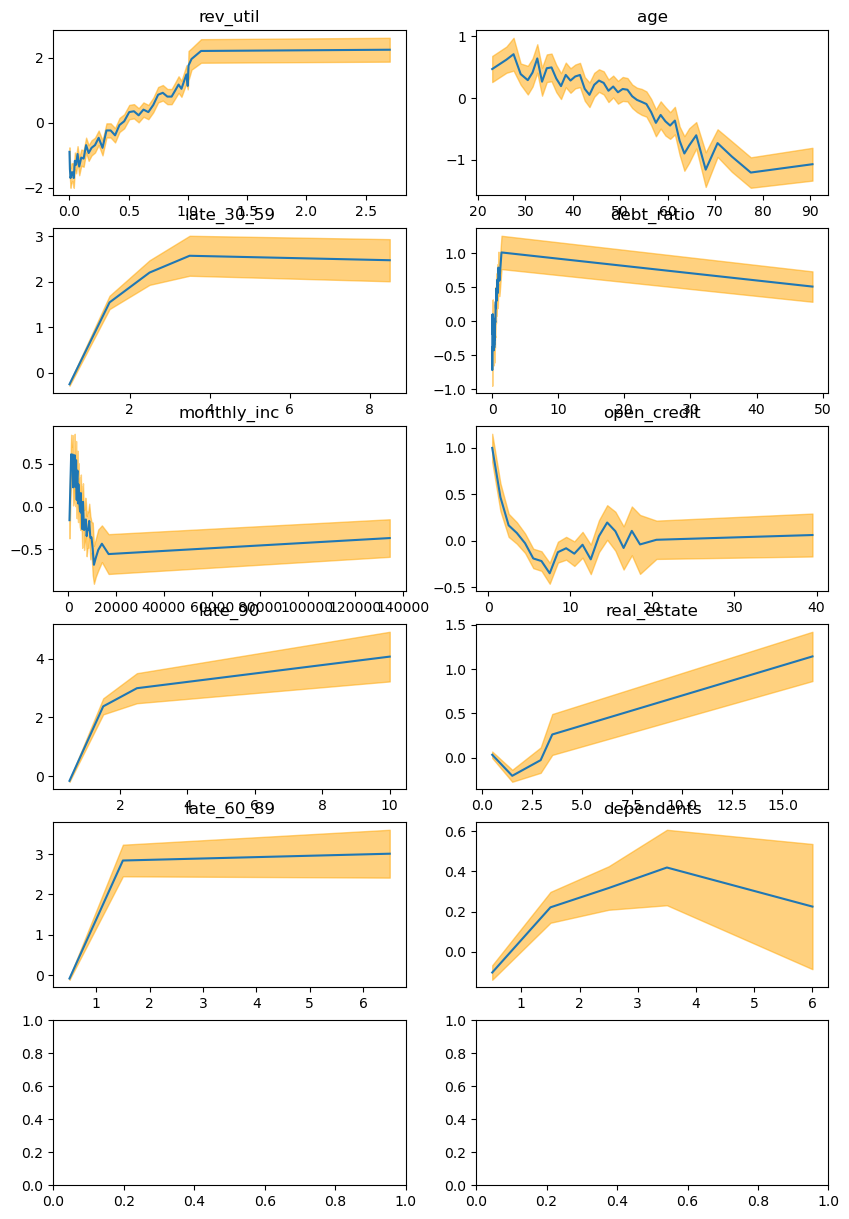

In [22]:
fig, axs = plt.subplots(6, 2, figsize=(10, 15))

# get columns names for dictionary (convert to list) and remove binned features entry
# del dict_log_odds['binned_feature']
col_names = list(dict_log_odds.keys())

for i, ax in enumerate(axs.flatten()):

    # get column name
    column_name = str(col_names[i])
    # plot 
    ax.plot(dict_log_odds[f'{column_name}'][f'bins'], dict_log_odds[f'{column_name}'][f'log_odds'])
    # fill in 95% confidence interval
    ax.fill_between(dict_log_odds[f'{column_name}'][f'bins'], 
                    y1=dict_log_odds[f'{column_name}'][f'ci_upper'], 
                    y2=dict_log_odds[f'{column_name}'][f'ci_lower'], alpha=0.5, color='orange')

    ax.set_title(column_name)

['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc', 'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents', 'binned_feature']


KeyError: 'bins'

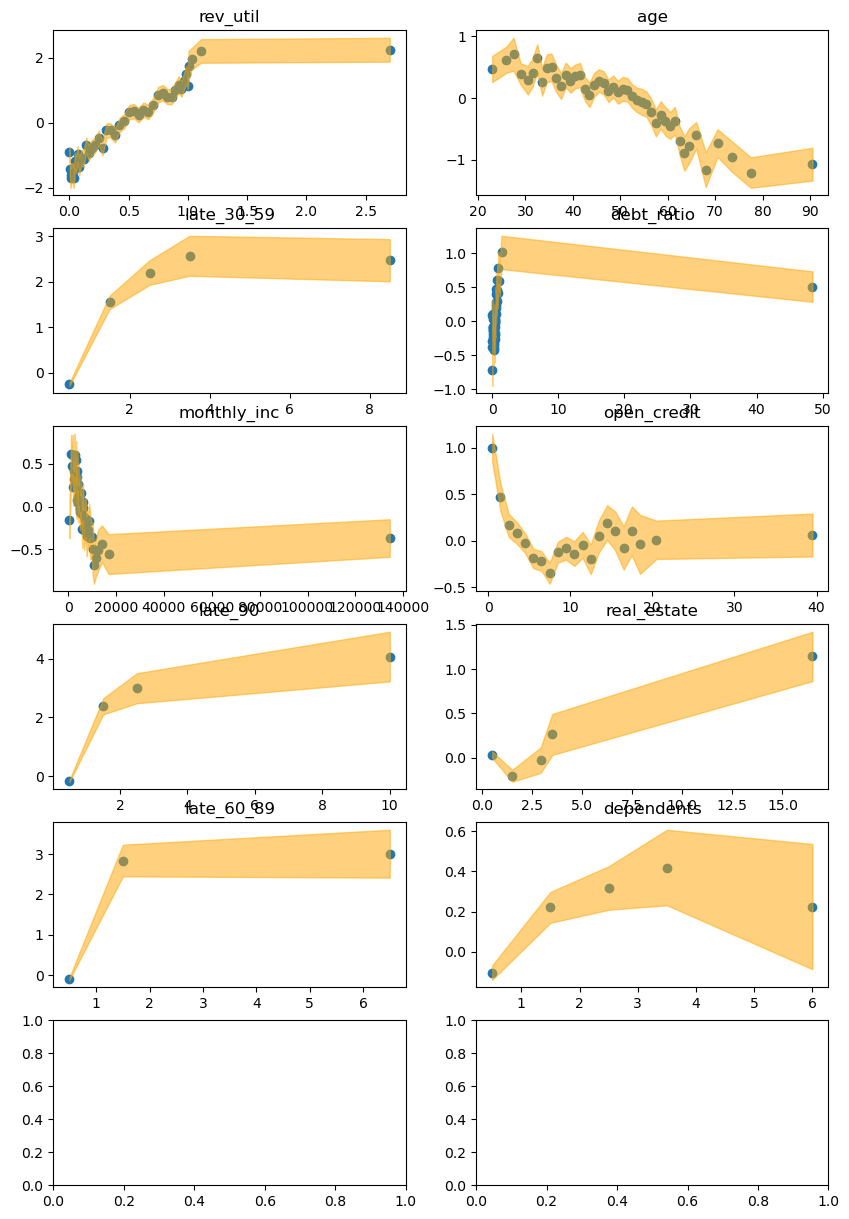

In [ ]:
fig, axs = plt.subplots(6, 2, figsize=(10, 15))

# get columns names for dictionary (convert to list) and remove binned features entry
col_names = list(dict_log_odds.keys())

print(col_names)

for i, ax in enumerate(axs.flatten()):

    # get column name
    column_name = str(col_names[i])
    # plot 
    ax.scatter(dict_log_odds[f'{column_name}'][f'bins'], dict_log_odds[f'{column_name}'][f'log_odds'])
    # fill in 95% confidence interval
    ax.fill_between(dict_log_odds[f'{column_name}'][f'bins'], 
                    y1=dict_log_odds[f'{column_name}'][f'ci_upper'], 
                    y2=dict_log_odds[f'{column_name}'][f'ci_lower'], alpha=0.5, color='orange')    
    ax.set_title(column_name)


    # plotting binned data against log of the odds, can see that non-linear relationship with some features

    # odds of default seems to taper out as income is increased, revolving utilisation is increased, 
`   # as well as open credit, in a -log like like pattern`

['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc', 'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents', 'binned_feature']


KeyError: 'bins'

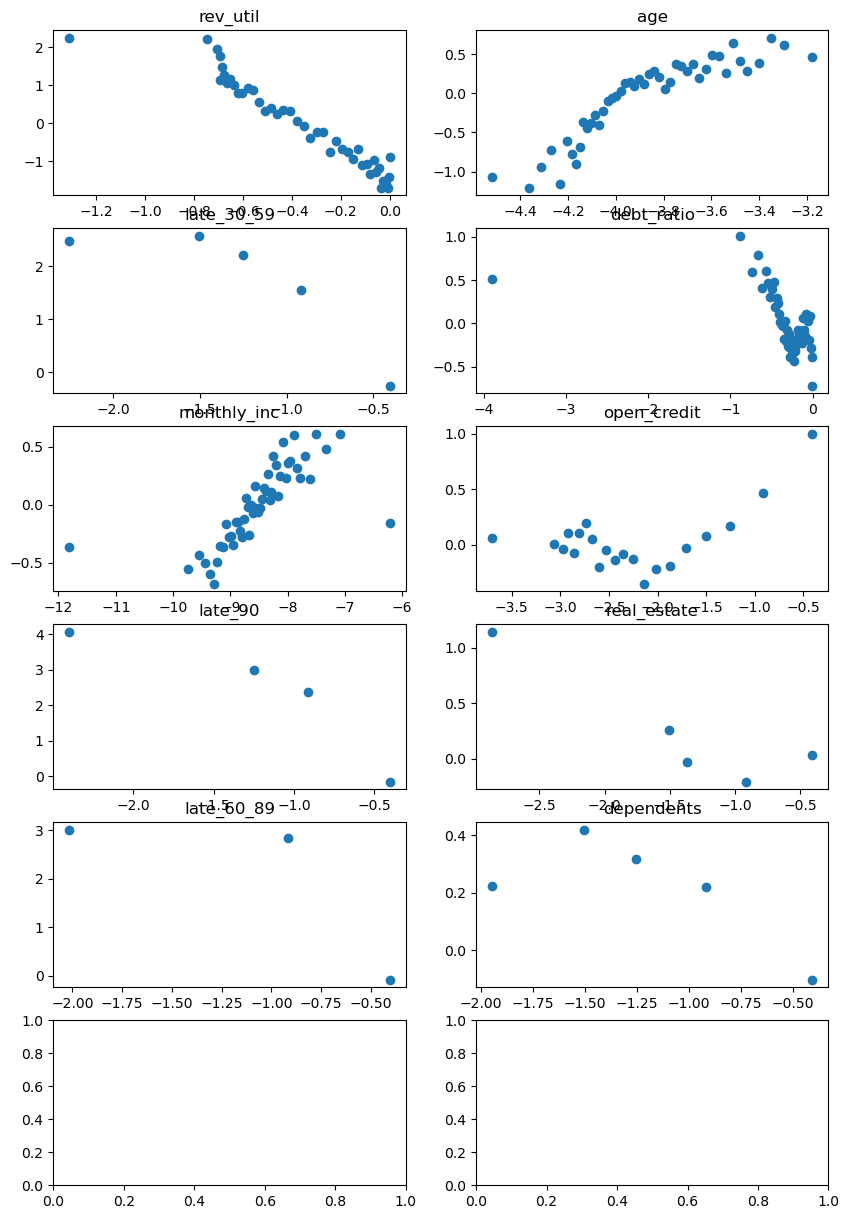

In [ ]:
fig, axs = plt.subplots(6, 2, figsize=(10, 15))

# get columns names for dictionary (convert to list) and remove binned features entry
col_names = list(dict_log_odds.keys())

print(col_names)

for i, ax in enumerate(axs.flatten()):

    # get column name
    column_name = str(col_names[i])
    # plot negative log of variables
    ax.scatter(-np.log1p(dict_log_odds[f'{column_name}'][f'bins']), dict_log_odds[f'{column_name}'][f'log_odds'])

    # for seaborn, specify ax argument for axis to apply plot to    
    ax.set_title(column_name)

# when plot negative log of variable, can see that get more or less linear for income, debt ratio and for
# revolving utilisation. spreads out data points in tightened region of the graph. 